## Check CAMS data

In [1]:
# import 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np
import xarray as xr
import sys
from utilities import find_best_grid_point, get_station_coords,form_xdate, get_anomalies
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import mplotutils as mpu

from plotting import tol_colors # color schemes from https://personal.sron.nl/~pault/

#activate interactive figures
%matplotlib widget
#activate autoreload
%load_ext autoreload

## Add parent directory to syspath
parent_dir = os.path.abspath(os.path.join(os.path.dirname('.'), '..'))
if not parent_dir in sys.path:
    sys.path.append(parent_dir)

# File path
data_path = "../data/"

In [2]:
## Read all data
%autoreload 2
from analyses_level2.read_wdc_data import AvailableData, create_data_reader


# if New data is added to ./data folder, adapt the dictionary in AvailableData
all_data = list(AvailableData)
print(all_data)

#####---------- TO ADAPT ---------------#####
selected_data = ['CO2', 'CO2_flask', 
                 'CO', 'CO_flask', 
                 'CH4', 'CH4_flask', 
                 'O3'
                 ] # define data to read in. If empty, all data is used 
## 
processing_kwargs = { 
    'FLASK_FLAG_CORR' : True # exclude flagged flask-data
}
#####-----------------------------------#####

datasets = [] # initialize list of all datasets 
# read in data
for sel in (selected_data if selected_data else all_data):
    #define where the data has to be read from
    data_reader =  create_data_reader(data_path=data_path,dataset=sel,**processing_kwargs) #creates an instance of the desired data_reader class
    print(f"Data from {data_reader.__class__.__name__} for {sel}:")

    # call the data-reading function on that instance: 
    data = data_reader.read_data() 
    # call the data-processing
    data = data_reader.process_data(data)

    # prepare merged dataset
    data = data.drop(columns='endtime') # problem when merging datasets (because of NaT?), so better remove endtime
    ds = data.to_xarray()
    ds = ds.assign_coords(dataset=sel)
    ds['species'] = data_reader.species
    ds['unit']  = np.unique(ds.unit.dropna(dim='time'))[0]
    datasets.append(ds)

# save all in one xarray dataset
ds_all = xr.concat(datasets,dim="dataset")


['CO2', 'CO2_flask', 'CO', 'CO_flask', 'CO_2002-2006', 'CH4', 'CH4_flask', 'O3', 'aerosols_2015', 'aerosols', 'other_gases_ebas', 'other_gases_wdc', 'meteo']
Data from wdcGHGReader for CO2:
Data from wdcFlaskReader for CO2_flask:
Data from wdcGHGReader for CO:
Data from wdcFlaskReader for CO_flask:
Data from wdcGHGReader for CH4:
Data from wdcFlaskReader for CH4_flask:
Data from ebasReader for O3:


In [3]:
cams_best_grid = xr.open_dataset(f"{data_path}/cams/cams_best_grid_MKN.nc")

In [4]:
## resample observations
# remove unnecessary variables for simplication
variables_to_keep = ["time", "dataset", "value", "value_unc", "unit", "species"]
ds_all_simple = ds_all.drop_vars(set(ds_all.variables) - set(variables_to_keep))


# Resample only time-dependent variables
time_dependent_variables = [
    var for var in ds_all_simple.data_vars if "time" in ds_all_simple[var].dims
]
non_time_dependent_variables = [
    var
    for var in ds_all_simple.data_vars
    if var not in time_dependent_variables or not "time"
]

ds_all_3h = (
    ds_all_simple[time_dependent_variables].resample(time="3h").mean(keep_attrs=True)
)
ds_all_6h = (
    ds_all_simple[time_dependent_variables].resample(time="6h").mean(keep_attrs=True)
)
# add non-time dependent variables again
for var in non_time_dependent_variables:
    ds_all_3h[var] = ds_all_simple[var]
    ds_all_6h[var] = ds_all_simple[var]

##### Check the selected CAMS grids
This only works when the full CAMS data was loaded. 
If you do not have locally stored cams data (see analyses_stebysteb.ipynb), skip this and go to the next section

In [5]:
# Read all full cams datasets
dir_data_cams = r"../data/cams"
cams_invgg_co2 = xr.open_dataset(dir_data_cams + r"/cams_invGG_co2_2020_2023_MKN.nc")
cams_invgg_ch4 = xr.open_dataset(dir_data_cams + r"/cams_invGG_ch4_2020_2021_MKN.nc")
cams_eac4 = xr.open_dataset(dir_data_cams + r"/cams_eac4_2003_2022_MKN.nc")
cams_egg4 = xr.open_dataset(dir_data_cams + r"/cams_egg4_2003_2020_MKN.nc")

cams_gfas = xr.open_dataset(dir_data_cams + r"/cams_gfas_2020_2023.nc")

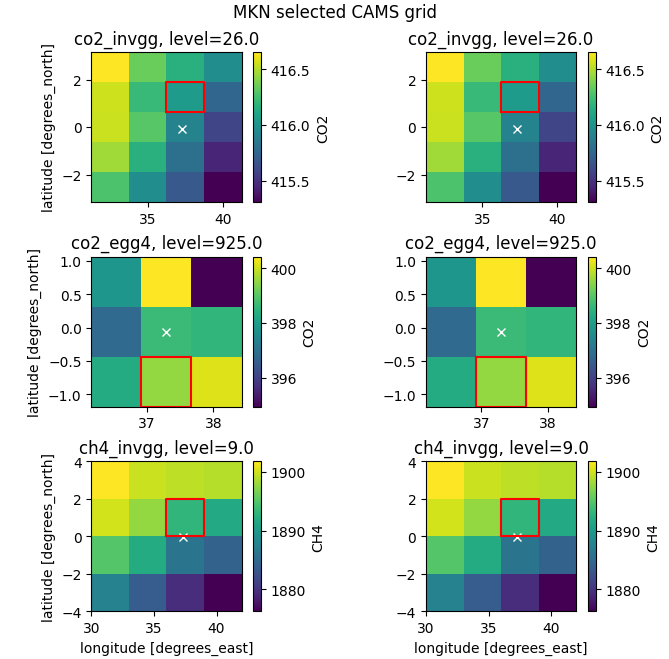

In [6]:
## Show which grids are selcted in cams data
# to obtain pressure at levels for invgg cams data: see https://confluence.ecmwf.int/display/CKB/ERA5%3A+compute+pressure+and+geopotential+on+model+levels%2C+geopotential+height+and+geometric+height

# mkn station:

lat, lon, alt = get_station_coords("MKN")


fig, axs = plt.subplots(
    3,
    2,
    figsize=(10, 8),
    layout="constrained",
)

for r, (ds_name, ax_row) in enumerate(zip(cams_best_grid.dataset, axs)):
    for c, ax in enumerate(ax_row):
        if ds_name == "co2_invgg":
            cams_sel = cams_invgg_co2["CO2"]

        elif ds_name == "co2_egg4":
            cams_sel = cams_egg4["CO2"]

        # CH4
        elif ds_name == "ch4_invgg":
            cams_sel = cams_invgg_ch4["CH4"]

        elif ds_name == "ch4_egg4":
            cams_sel = cams_egg4["CH4"]

        # CO
        elif ds_name == "co_eac4":
            cams_sel = cams_eac4["CO"]

        # O3
        elif ds_name == "o3_eac4":
            cams_sel = cams_eac4["O3"]

        # selected grid:
        cams_lev = cams_best_grid.sel(dataset=ds_name).level.values
        cams_lat = cams_best_grid.sel(dataset=ds_name).latitude.values
        cams_lon = cams_best_grid.sel(dataset=ds_name).longitude.values
        cams_sel.sel(level=cams_lev).mean(dim="time").plot(ax=ax)

        ax.plot(lon, lat, marker="x", color="w")  # mt. kenya station

        # Draw a red rectangle around the selected grid cell

        dy = np.unique(np.diff(cams_sel.latitude))
        dx = np.unique(np.diff(cams_sel.longitude))
        lat_min, lat_max = cams_lat - dy / 2, cams_lat + dy / 2
        lon_min, lon_max = cams_lon - dx / 2, cams_lon + dx / 2
        ax.plot(
            [lon_min, lon_max, lon_max, lon_min, lon_min],
            [lat_min, lat_min, lat_max, lat_max, lat_min],
            color="red",
        )

        ax.set_title(f"{ds_name.values}, level={str(cams_lev)}")
        if r != 2:
            ax.set_xlabel("")  # xlabel only in the bottom
        if c != 0:
            ax.set_ylabel("")  # ylabel only on the left

plt.suptitle("MKN selected CAMS grid")
plt.setp(axs, box_aspect=1)  # get quadratic plots
mpu.set_map_layout(axs)  # better spaces between map-figures

plt.show()

### Compare CAMS with measurement data at MKN

In [7]:
###### --- FOR ALL comparison FIGURES --- #####
## Select the time period and species to plot


tsel1 = "2020-01-01"
tsel2 = "2023-12-31"

sel_species = ds_all.species
unique_species = np.unique(sel_species)

species_sel = unique_species

# species_sel = ["CO2", "CO"]

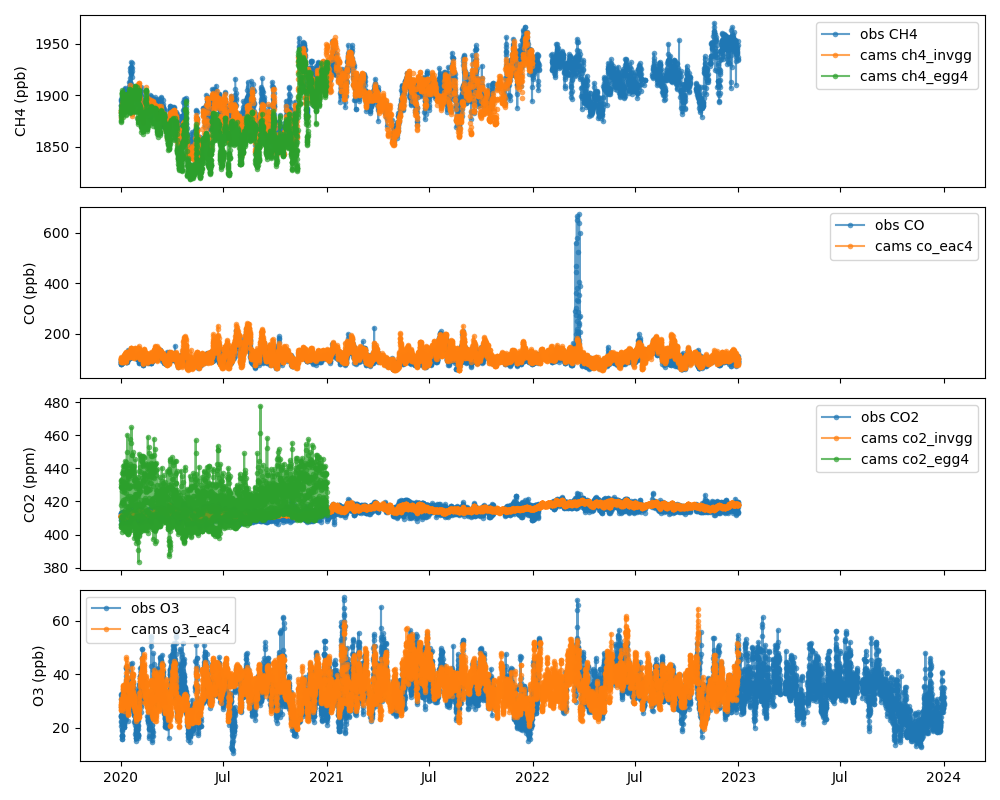

In [8]:
## plot cams versus observations
alpha = 0.7
ms = 8

fig, axs = plt.subplots(
    len(species_sel), 1, sharex=True, figsize=(10, len(species_sel) * 2)
)
for s, ax in zip(species_sel, axs):
    if s == "CH4":
        ds = ds_all_6h  # ch4 has 6h resolution
    else:
        ds = ds_all_3h

    # OR: use hourly observations
    # ds = ds_all

    ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)
    # select cams datasets that exist for this species
    cams_datasets_sel = [
        cams_sel
        for cams_sel in cams_best_grid.dataset.values
        if f"{s.lower()}_" in cams_sel
    ]
    cams = cams_best_grid.sel(dataset=cams_datasets_sel, time=slice(tsel1, tsel2))

    # function to plot each subplot
    def plot_data(ds, label):
        if "flask" in str(ds.dataset.values):
            m = "."
            l = ""
        else:
            m = "."
            l = "-"
        ds.plot(
            ax=ax,
            ls=l,
            marker=m,
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"{label} {str(ds.dataset.values)}",
        )

    # plot obs
    if len(ds_sel.dataset) > 1:  # several obs datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in ds_sel.dataset
            if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
        ]
        for ds_i in ds_sel.sel(dataset=variables_to_keep).dataset:
            plot_data(ds_sel.sel(dataset=ds_i.values)["value"], "obs")
    else:
        plot_data(ds_sel.sel(dataset=s)["value"], "obs")

    # plot cams
    if len(cams.dataset) > 1:  # several cams datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in cams.dataset
            if cams.sel(dataset=spec)["value"].isnull().all() == False
        ]
        for cams_i in cams.sel(dataset=variables_to_keep).dataset:
            plot_data(cams.sel(dataset=cams_i)["value"], "cams")
    else:
        plot_data(cams.isel(dataset=0)["value"], "cams")

    ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
    ax.set_xlabel("")
    ax.set_title("")
    ax.legend()
plt.tight_layout()
plt.show()

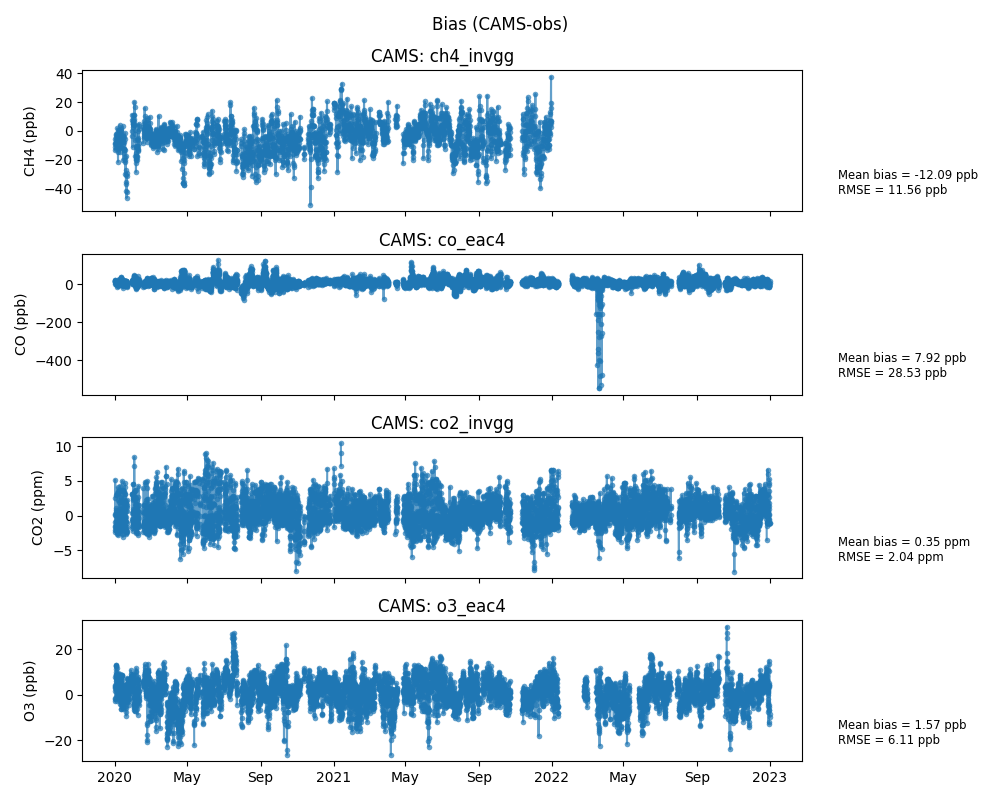

In [9]:
## plot bias between cams and observations
def root_mean_squared_error(x, y):
    return np.sqrt(((x - y) ** 2).mean(dim="time"))


def mean_bias(x, y):
    return (x).mean(dim="time") - (y).mean(dim="time")


alpha = 0.7
ms = 8

fig, axs = plt.subplots(
    len(species_sel), 1, sharex=True, figsize=(10, len(species_sel) * 2)
)
for s, ax in zip(species_sel, axs):
    # select CAMS for which I want to show the bias
    if s == "CO2":
        cams_dataset = "co2_invgg"  # "co2_egg4"
    elif s == "CH4":
        cams_dataset = "ch4_invgg"  # "ch4_egg4"
    elif s == "CO":
        cams_dataset = "co_eac4"
    elif s == "O3":
        cams_dataset = "o3_eac4"

    # select obs, ch4_invgg has 6h resolution
    if cams_dataset == "ch4_invgg":
        ds = ds_all_6h  # ch4 has 6h resolution
    else:
        ds = ds_all_3h

    ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)

    # function to plot each subplot
    def plot_bias(x):
        x.plot(
            ax=ax,
            ls="-",
            marker=".",
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"cams-obs",
        )

    # plot bias
    cams = cams_best_grid.sel(dataset=cams_dataset, time=slice(tsel1, tsel2))
    if len(ds_sel.dataset) > 1:  # several datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in ds_sel.dataset
            if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
        ]
        for ii in ds_sel.sel(dataset=variables_to_keep).dataset:
            plot_bias(cams["value"] - ds_sel.sel(dataset=ii)["value"])
    else:
        plot_bias(cams["value"] - ds_sel.sel(dataset=s)["value"])

    mbias = mean_bias(cams["value"], ds_sel.sel(dataset=s)["value"]).values
    rmse = root_mean_squared_error(cams["value"], ds_sel.sel(dataset=s)["value"]).values
    ax.text(
        1.05,
        0.2,
        f"Mean bias = {mbias:.2f} {ds_sel.unit[0].values} \nRMSE = {rmse:.2f} {ds_sel.unit[0].values}",
        horizontalalignment="left",
        verticalalignment="center",
        transform=ax.transAxes,
        fontsize="small",
    )

    ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
    ax.set_xlabel("")
    ax.set_title(f"CAMS: {cams_dataset}")
    # ax.legend()
plt.suptitle("Bias (CAMS-obs)")
plt.tight_layout()

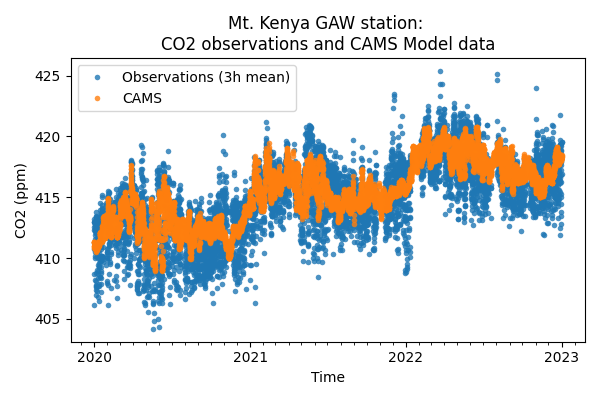

In [10]:
## Figure for single species
data_sel = "CO2"
cams_dataset = "co2_invgg"

obs = ds_all_3h.sel(time=slice(tsel1, tsel2), dataset=data_sel, drop=True)
cams = cams_best_grid.sel(dataset=cams_dataset, time=slice(tsel1, tsel2))

fig, ax = plt.subplots(figsize=(6, 4))
alpha = 0.8
ms = 8

pl_obs = obs["value"].plot(
    marker=".",
    ls="",
    label="Observations (3h mean)",
    alpha=alpha,
    markeredgewidth=0,
    markersize=ms,
)
pl_cams = cams["value"].plot(
    marker=".", ls="", label="CAMS", alpha=alpha, markeredgewidth=0, markersize=ms
)
mw_days = 5  # moving window days
mw = 3 * 8 * mw_days  #  moving window
# cams_best.rolling(time=mw,center=True,min_periods=mw/2).mean().plot(ls='-',c='k')#c=pl_cams[0].get_color())
# obs3h.to_xarray().rolling(time=mw,center=True,min_periods=mw/2).mean().plot(ls='-',c=pl_obs[0].get_color())
plt.ylabel("CO2 (ppm)")
plt.xlabel("Time")
plt.legend()
plt.title("Mt. Kenya GAW station: \nCO2 observations and CAMS Model data")
form_xdate(ax, "Y", 1, "")
fig_format = "png"
plt.tight_layout()
# plt.savefig(fr'.\analyses\MKN_co2_gaw_cams_inv.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')

# plt.savefig(f'.\\analyses\MKN_co2_gaw_cams_inv_mw{mw_days}d.{fig_format}',format=fig_format,dpi=400,transparent=False,facecolor='white')

c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\analyses_level2\utilities.py:88: RuntimeWarning: invalid value encountered in divide
  ds_m[var + '_anom_stdz'] = xr.apply_ufunc(lambda x, m, s: (x - m) / s,
c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\analyses_level2\utilities.py:88: RuntimeWarning: invalid value encountered in divide
  ds_m[var + '_anom_stdz'] = xr.apply_ufunc(lambda x, m, s: (x - m) / s,
c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\analyses_level2\utilities.py:88: RuntimeWarning: invalid value encountered in divide
  ds_m[var + '_anom_stdz'] = xr.apply_ufunc(lambda x, m, s: (x - m) / s,
c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\analyses_level2\utilities.py:88: RuntimeWarning: invalid value encountered in divide
  ds_m[var + '_anom_stdz'] = xr.apply_ufunc(lambda x, m, s: (x - m) / s,
c:\Users\leob\Documents\Data_analyses\KADI\gawkenya\analyses_level2\utilities.py:88: RuntimeWarning: invalid value encountered in divide
  ds_m[var + '_anom_std

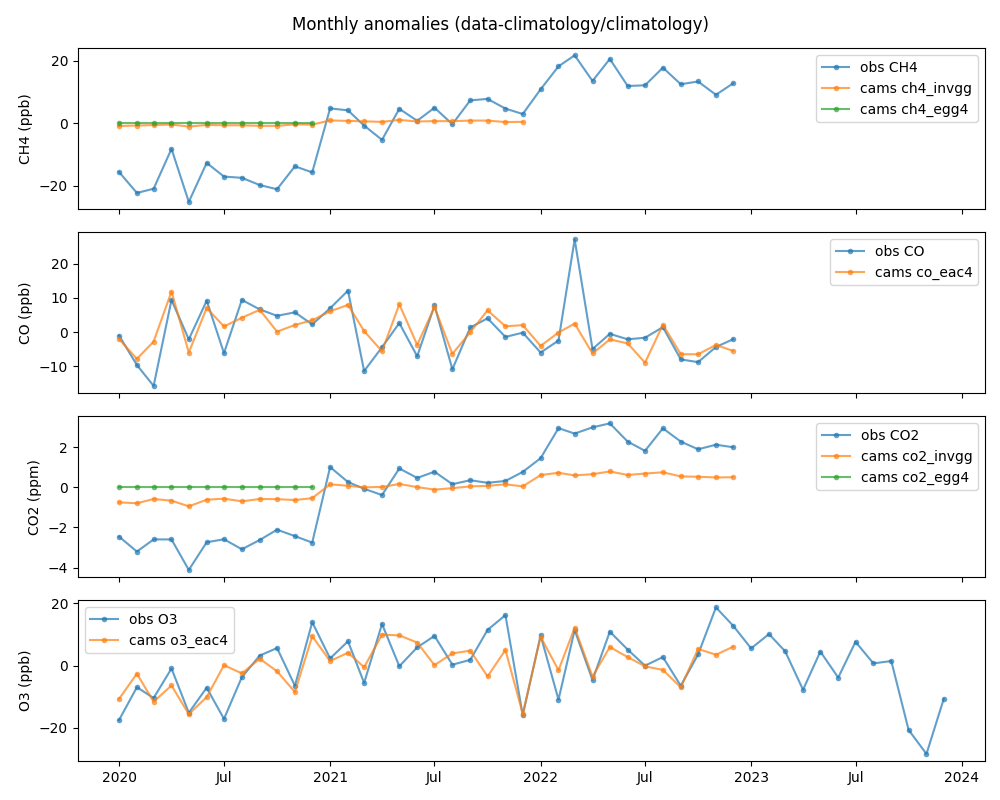

In [11]:
### Monthly anomalies

## plot cams versus observations
alpha = 0.7
ms = 8

fig, axs = plt.subplots(
    len(species_sel), 1, sharex=True, figsize=(10, len(species_sel) * 2)
)
for s, ax in zip(species_sel, axs):
    ds = ds_all  # hourly observations

    ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)
    # select cams datasets that exist for this species
    cams_datasets_sel = [
        cams_sel
        for cams_sel in cams_best_grid.dataset.values
        if f"{s.lower()}_" in cams_sel
    ]
    cams = cams_best_grid.sel(dataset=cams_datasets_sel, time=slice(tsel1, tsel2))

    ## get monthly anomalies
    ds_m = get_anomalies(
        ds_sel.resample(time="MS").mean(), var="value", yr1=2020, yr2=2023
    )
    cams_m = get_anomalies(
        cams.resample(time="MS").mean(), var="value", yr1=2020, yr2=2023
    )

    # function to plot each subplot
    def plot_data(ds, label):
        if "flask" in str(ds.dataset.values):
            m = "."
            l = ""
        else:
            m = "."
            l = "-"
        ds.plot(
            ax=ax,
            ls=l,
            marker=m,
            markeredgewidth=0,
            alpha=alpha,
            markersize=ms,
            label=f"{label} {str(ds.dataset.values)}",
        )

    # plot obs
    var_to_plot = "value_anom_per"
    if len(ds_m.dataset) > 1:  # several obs datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in ds_m.dataset
            if ds_m.sel(dataset=spec)[var_to_plot].isnull().all() == False
        ]
        for ds_i in ds_m.sel(dataset=variables_to_keep).dataset:
            plot_data(ds_m.sel(dataset=ds_i.values)["value_anom"], "obs")
    else:
        plot_data(ds_m.sel(dataset=s)[var_to_plot], "obs")

    # plot cams
    if len(cams_m.dataset) > 1:  # several cams datasets with same species
        # plot only if we have data in our given time period:
        variables_to_keep = [
            spec.dataset.values
            for spec in cams.dataset
            if cams_m.sel(dataset=spec)[var_to_plot].isnull().all() == False
        ]
        for cams_i in cams_m.sel(dataset=variables_to_keep).dataset:
            plot_data(cams_m.sel(dataset=cams_i)[var_to_plot], "cams")
    else:
        plot_data(cams_m.isel(dataset=0)[var_to_plot], "cams")

    ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
    ax.set_xlabel("")
    ax.set_title("")
    ax.legend()
plt.suptitle("Monthly anomalies (data-climatology/climatology)")
plt.tight_layout()
plt.show()

### Check Seasonal and daily cycles

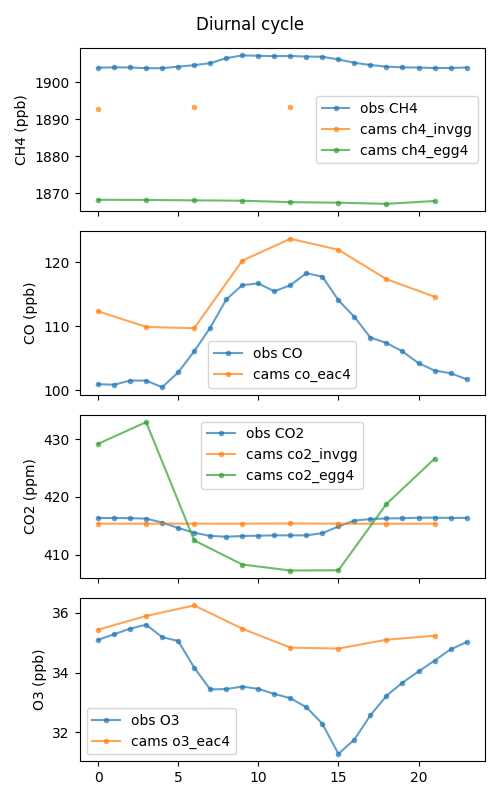

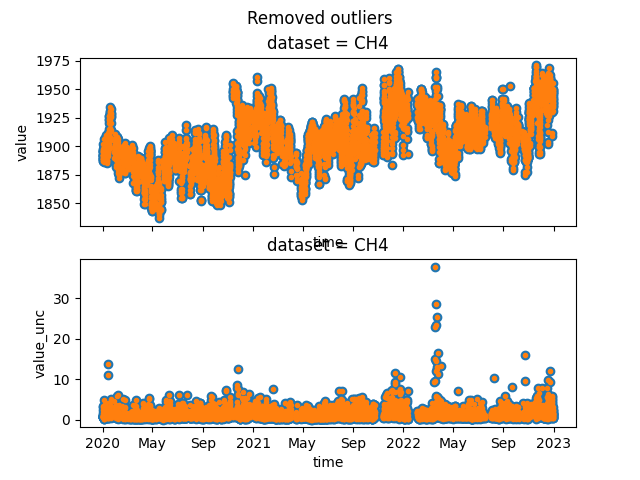

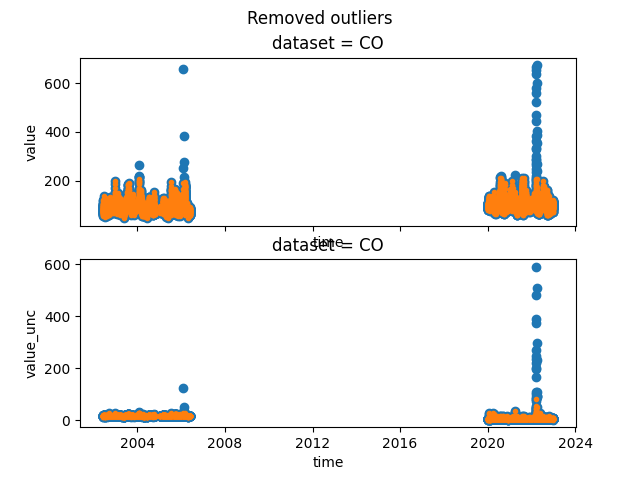

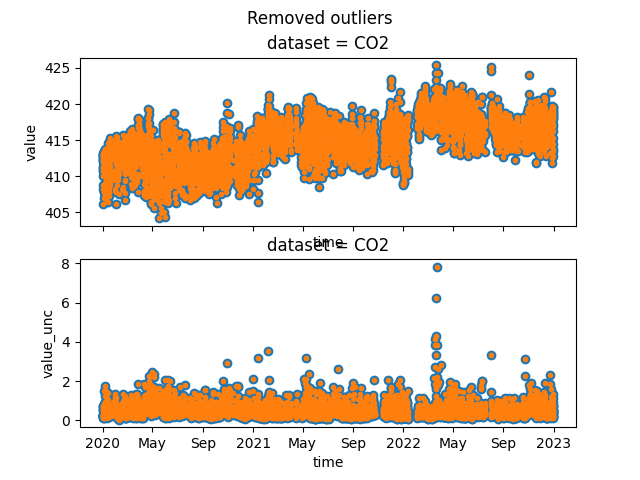

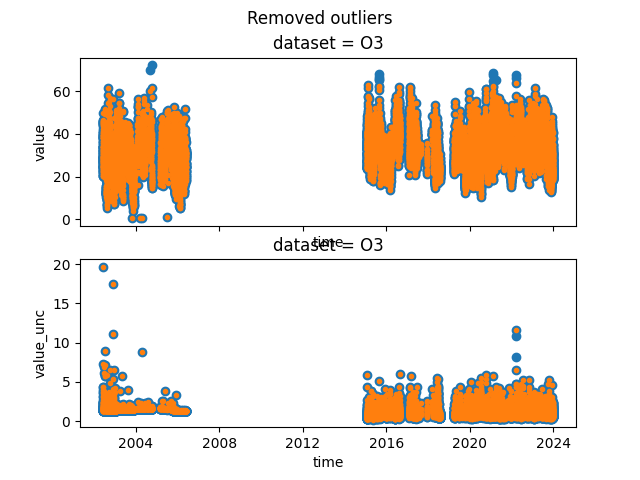

In [14]:
## Remove some outliers, especially wild fire CO

import process_data

ds_all_3h_rem_out = process_data.rem_out(ds_all_3h, std_fac=10, z_threshold=4)

## plot removed data
var = "value"

for s in species_sel:

    f, axs = plt.subplots(2, 1, sharex=True)
    plt.suptitle("Removed outliers")
    ds_all_3h.sel(dataset=s)[var].plot(ls="", marker="o", ax=axs[0])
    ds_all_3h.sel(dataset=s)[var + "_unc"].plot(ls="", marker="o", ax=axs[1])
    # new data:
    ds_all_3h_rem_out.sel(dataset=s)[var].plot(ls="", marker=".", ax=axs[0])
    ds_all_3h_rem_out.sel(dataset=s)[var + "_unc"].plot(ls="", marker=".", ax=axs[1])
    plt.show()

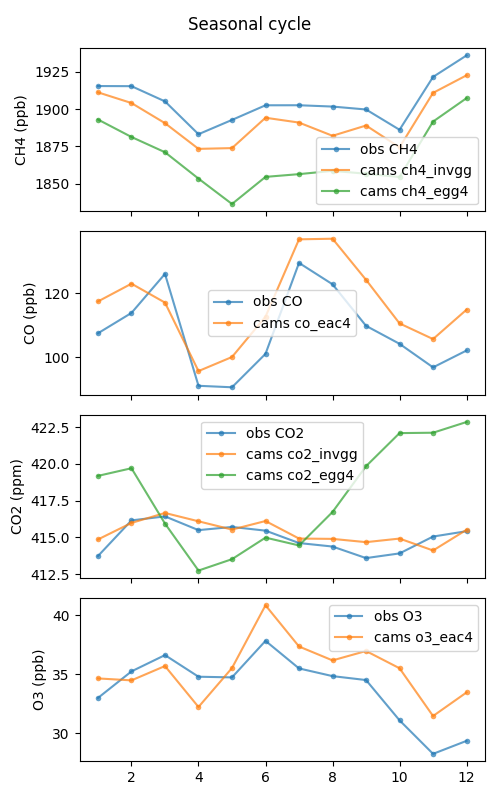

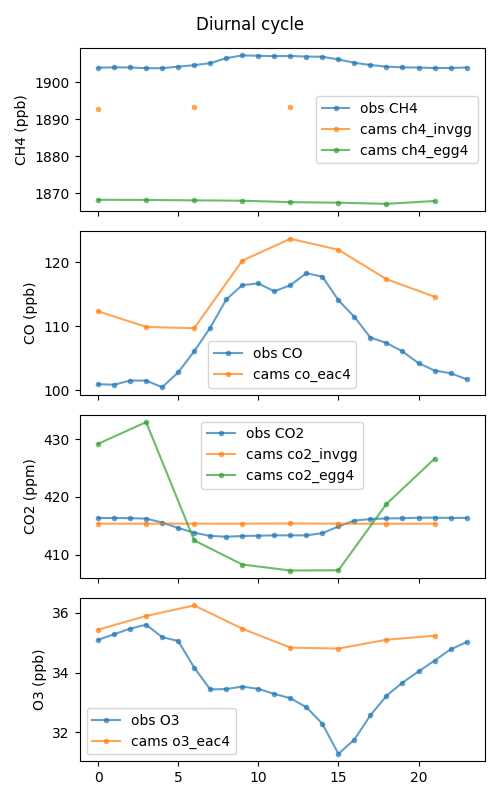

In [13]:
## plot  SEASONAL CYCLE and DIURNAL cams versus observations

alpha = 0.7
ms = 8

# dont use all cams-products
cams_mask = ~np.isin(cams_best_grid["dataset"], "co2_egg4", "ch4_egg4")
cams_use = cams_best_grid.sel(dataset=cams_mask)
# Or: use all:
cams_use = cams_best_grid

for freq in ["month", "hour"]:
    fig, axs = plt.subplots(
        len(species_sel), 1, sharex=True, figsize=(5, len(species_sel) * 2)
    )
    for s, ax in zip(species_sel, axs):
        if s == "CH4":
            ds = ds_all  # ch4 has 6h resolution
        else:
            ds = ds_all

        ds_sel = ds.sel(time=slice(tsel1, tsel2)).where(ds.species == s, drop=True)
        # select cams datasets that exist for this species
        cams_datasets_sel = [
            cams_sel
            for cams_sel in cams_use.dataset.values
            if f"{s.lower()}_" in cams_sel
        ]
        cams = cams_use.sel(dataset=cams_datasets_sel, time=slice(tsel1, tsel2))

        # function to plot each subplot
        def plot_data(ds, label):
            ds.groupby(f"time.{freq}").mean().plot(
                ax=ax,
                ls="-",
                marker=".",
                markeredgewidth=0,
                alpha=alpha,
                markersize=ms,
                label=f"{label} {str(ds.dataset.values)}",
            )

        # plot obs
        if len(ds_sel.dataset) > 1:  # several obs datasets with same species
            # plot only if we have data in our given time period:
            variables_to_keep = [
                spec.dataset.values
                for spec in ds_sel.dataset
                if ds_sel.sel(dataset=spec)["value"].isnull().all() == False
            ]
            for ds_i in ds_sel.sel(dataset=variables_to_keep).dataset:
                plot_data(ds_sel.sel(dataset=ds_i.values)["value"], "obs")
        else:
            plot_data(ds_sel.sel(dataset=s)["value"], "obs")

        # plot cams
        if len(cams.dataset) > 1:  # several cams datasets with same species
            # plot only if we have data in our given time period:
            variables_to_keep = [
                spec.dataset.values
                for spec in cams.dataset
                if cams.sel(dataset=spec)["value"].isnull().all() == False
            ]
            for cams_i in cams.sel(dataset=variables_to_keep).dataset:
                plot_data(cams.sel(dataset=cams_i)["value"], "cams")
        else:
            plot_data(cams.isel(dataset=0)["value"], "cams")

        ax.set_ylabel(f"{ds_sel.species[0].values} ({ds_sel.unit[0].values})")
        ax.set_xlabel("")
        ax.set_title("")
        ax.legend()

    if freq == "month":
        tit = "Seasonal"
    elif freq == "hour":
        tit = "Diurnal"

    plt.suptitle(f"{tit} cycle")
    plt.tight_layout()
    plt.show()